# Module 7 Code Exercise

In [22]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import norm
import plotly_express as px
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='ticks')
%matplotlib inline

OHCO = ['genre', 'author', 'book', 'chapter', 'para_num', 'sent_num', 'token_num']

TOKENS = pd.read_csv('novels-TOKENS.csv')
LIB = pd.read_csv('novels-LIB.csv') 
VOCAB = pd.read_csv('novels-VOCAB.csv').set_index('term_id')

TOKENS = TOKENS.merge(LIB, on='book', how='left')

In [23]:
TOKENS_FILTERED = TOKENS[~TOKENS['pos'].isin(['NNP', 'NNPS'])]

BOW = (TOKENS_FILTERED
       .groupby(['book', 'term_id'])
       .size()
       .unstack('term_id')
       .fillna(0))

DTM = BOW.apply(lambda x: x / x.sum(), axis=1)

N_docs = BOW.shape[0]
DF = BOW[BOW > 0].count()
IDF = np.log(N_docs / DF)

TFIDF = DTM * IDF
VOCAB_FILTERED = VOCAB.loc[VOCAB.index.isin(TFIDF.columns)]
VOCAB_FILTERED = VOCAB_FILTERED[VOCAB_FILTERED['tfidf_sum'] > 0]
TOP_TERMS = VOCAB_FILTERED.nlargest(4000, 'tfidf_sum').index
TFIDF = TFIDF[TOP_TERMS]

In [24]:
TFIDF = TFIDF.apply(lambda x: x / norm(x), axis=1)
TFIDF = TFIDF - TFIDF.mean()

In [25]:
TERM_IDX = TFIDF.columns
COV = TFIDF.T.dot(TFIDF) / (TFIDF.shape[0] - 1)

print(f"COV shape: {COV.shape}")

COV shape: (4000, 4000)


In [26]:
eig_vals, eig_vecs = np.linalg.eigh(COV)
eig_vals = np.maximum(eig_vals, 0)

EIG_VAL = pd.DataFrame(eig_vals, index=TERM_IDX, columns=['eig_val'])
EIG_VAL.index.name = 'term_id'

EIG_VEC = pd.DataFrame(eig_vecs, index=TERM_IDX, columns=TERM_IDX)

EIG_PAIRS = EIG_VAL.join(EIG_VEC.T)

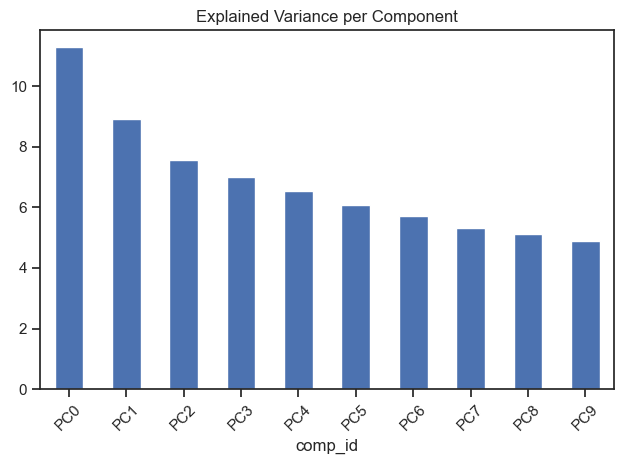

In [27]:
EIG_PAIRS['exp_var'] = np.round(
    (EIG_PAIRS['eig_val'] / EIG_PAIRS['eig_val'].sum()) * 100, 2
)

COMPS = (EIG_PAIRS
         .sort_values('exp_var', ascending=False)
         .head(10)
         .reset_index(drop=True))

COMPS.index = [f'PC{i}' for i in COMPS.index]
COMPS.index.name = 'comp_id'

COMPS['exp_var'].plot.bar(title='Explained Variance per Component', rot=45)
plt.tight_layout()
plt.show()

In [28]:
DCM = TFIDF.dot(COMPS[TERM_IDX].T)
DCM = DCM.join(LIB.set_index('book')[['author', 'genre']])

print(DCM.head())

                      PC0       PC1       PC2       PC3       PC4       PC5  \
book                                                                          
adventures      -0.414674  0.154768  0.018717  0.101120 -0.068881 -0.084367   
baskervilles    -0.059896  0.280826 -0.228741  0.174101  0.083135 -0.208844   
baskervilles    -0.059896  0.280826 -0.228741  0.174101  0.083135 -0.208844   
castleofotranto  0.250795 -0.503382 -0.471614  0.186572 -0.155916  0.104220   
christmascarole -0.115368  0.143619 -0.202334  0.028493  0.116896 -0.073036   

                      PC6       PC7       PC8       PC9   author genre  
book                                                                    
adventures      -0.080362  0.044591  0.072760  0.028814    doyle     d  
baskervilles     0.725743  0.178841 -0.167007  0.071379    doyle     d  
baskervilles     0.725743  0.178841 -0.167007  0.071379    doyle    nh  
castleofotranto -0.002728 -0.018512  0.018671 -0.017952  walpole     g  
christma

In [29]:
px.scatter(DCM, x='PC0', y='PC1', color='genre',
           hover_name=DCM.index,
           title='PC0 vs PC1 — by Genre').show()

px.scatter(DCM, x='PC0', y='PC1', color='author',
           hover_name=DCM.index,
           title='PC0 vs PC1 — by Author').show()

px.scatter(DCM, x='PC1', y='PC2', color='genre',
           hover_name=DCM.index,
           title='PC1 vs PC2 — by Genre').show()

px.scatter(DCM, x='PC1', y='PC2', color='author',
           hover_name=DCM.index,
           title='PC1 vs PC2 — by Author').show()

In [30]:
LOADINGS = COMPS[TERM_IDX].T
LOADINGS.index.name = 'term_id'
LOADINGS['term_str'] = LOADINGS.index.map(lambda x: VOCAB.loc[x, 'term_str'])

n = 10
for pc in ['PC0', 'PC1']:
    pos_words = LOADINGS.nlargest(n, pc)['term_str'].tolist()
    neg_words = LOADINGS.nsmallest(n, pc)['term_str'].tolist()
    print(f"\n{pc} (+): {pos_words}")
    print(f"{pc} (-): {neg_words}")



PC0 (+): ['corpse', 'dungeon', 'prince', 'fro', 'descent', 'clock', 'du', 'mansion', 'thou', 'hue']
PC0 (-): ['you', 'her', 'she', 'holmes', 'footnote', 'dont', 'your', 'though', 'launch', 'cab']

PC1 (+): ['moor', 'corpse', 'tuppence', 'launch', 'holmes', 'footnote', 'police', 'cab', 'dont', 'gang']
PC1 (-): ['her', 'tm', 'thou', 'she', 'thy', 'emily', 'thee', 'castle', 'edmund', 'electronic']


## Interpretation of the results:
The PCA analysis reveals that the first principal component (PC0) captures the strongest contrast in the corpus. We can see books seperate clearly by genre in the PC0 vs PC1 scatterplot. Gothic texts tend to appear on the positive side of PC0, while detective stories appear on the negative side. This suggests that PC0 represents the primary genre distinction between gothic and detective literature. PC1 separates texts by narrative focus and protagonist type and therefore captures the axis from active investigative narrative on one end to passive female-centered Gothic narrative on the other.

Together, PC0 and PC1 create a two-dimensional space that meaningfully separates the corpus along two independent literary axes: the era and register of the language, and the type of protagonist and narrative drive. Gothic novels cluster in the positive PC0 / negative PC1 quadrant, while detective fiction clusters in the negative PC0 / positive PC1 quadrant — consistent with what the scatter plots show.